<a href="https://colab.research.google.com/github/Mauricio-Fragoso-Mendoza/Simulacion-I/blob/main/An%C3%A1lisis_Estad%C3%ADstico_de_Datos_Simulados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install simpy
import numpy as np
import random as r
import simpy as sp
import statistics as st
import pandas as pd
import matplotlib.pyplot as plt

**Actividad:** Estimar $\int_0^1 e^{x^2} dx$ por Monte Carlo

*Solución:* Primero se graficará la expresión de la integral.

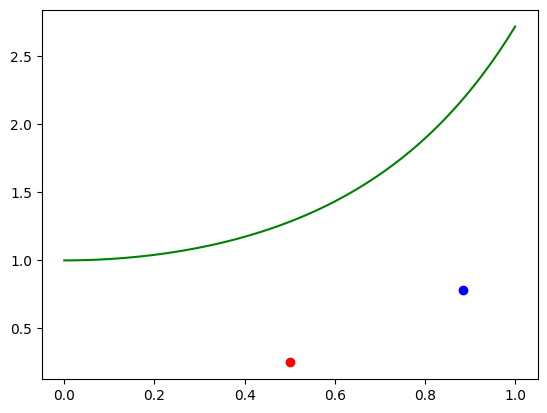

In [10]:
x = np.linspace(0, 1, 100)
plt.plot(x, np.exp(x**2), color= 'green')
plt.scatter(0.5, 0.25, color= 'red')
plt.scatter(r.uniform(0, 1),r.random(), color= 'blue')

Posteriormente, se generarán al menos 100 valores y el programa se detendrá cuando los errores estándar sean de 0.01 y 0.001

a) $\sigma = 0.01$

In [ ]:
def AEDS(n):
  datos = []
  for i in range(n):
    x = r.random()


In [11]:
def test_function(x):
  return(np.exp(x**2))

In [12]:
def integrate1(x1,x2,func=test_function,n=100):
    X=np.linspace(x1,x2,100)
    y1=0
    y2=max((func(X)))
    print(x1,x2,y1,y2)
    area=(x2-x1)*(y2-y1)
    check=[]
    xs=[]
    ys=[]
    for i in range(n):
        x=np.random.uniform(x1,x2,1)
        xs.append(x)
        y=np.random.uniform(y1,y2,1)
        ys.append(y)
        if abs(y)>abs(func(x)) or y<0:
            check.append(0)
        else:
            check.append(1)
    return(np.mean(check)*area,xs,ys,check)

0 1 0 2.718281828459045
1.6581519153600175
0 1 0 2.718281828459045


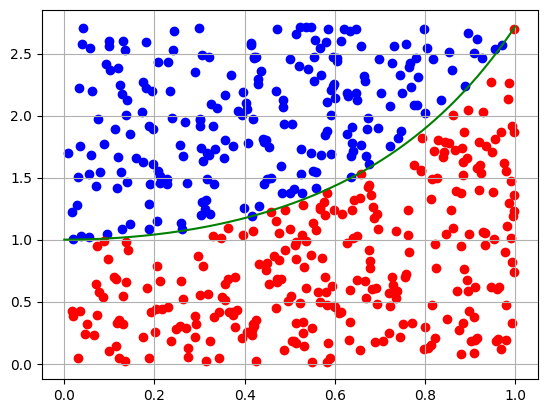

In [14]:
import pandas as pd

print(integrate1(0,1,test_function)[0])
_,x,y,c=integrate1(0,1,n=500)
df=pd.DataFrame()
df['x']=x
df['y']=y
df['c']=c

X=np.linspace(0,1,1000)
plt.grid(True)
plt.plot(X,test_function(X),color='green')
plt.scatter(df[df['c']==0]['x'],df[df['c']==0]['y'],color='blue')
plt.scatter(df[df['c']==1]['x'],df[df['c']==1]['y'],color='red')
plt.show()